In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

In [16]:
# -------- PATHS --------
input_dir = os.path.join(os.getcwd(), "extracted_csv")
output_dir = os.path.join(os.getcwd(), "processed_csv")

os.makedirs(output_dir, exist_ok=True)

csv_files = [f for f in os.listdir(input_dir) if f.endswith(".csv")]

print("Files found:")
for f in csv_files:
    print(f)

dataframes = []
filenames = []

Files found:
MPC_10_CS.1.csv
MPC_10_CS.csv
MPC_10_FV1.csv
MPC_10_FV2.csv
MPC_5_CS1.csv
MPC_5_CS2.csv
PD_CS_10.csv
PD_FV_10.csv
PD_FV_10_2.csv
PD_FV_5.csv


In [17]:
for file in csv_files:

    file_path = os.path.join(input_dir, file)
    df = pd.read_csv(file_path)

    # -------- REMOVE DUPLICATES --------
    df = df.drop_duplicates(subset="ros_time").reset_index(drop=True)
    # -------- TIME CONVERSION --------
    df["time_sec"] = df["ros_time"] - df["ros_time"].iloc[0]
    # -------- VELOCITY CONVERSION --------
    df["ego_velocity_kmph"] = df["ego_velocity"] * 3.6
    if "lead_velocity" in df.columns:
        df["lead_velocity_kmph"] = df["lead_velocity"] * 3.6
    # -------- SAVE PROCESSED CSV --------
    output_path = os.path.join(output_dir, file)
    df.to_csv(output_path, index=False)
    dataframes.append(df)
    filenames.append(file)

    print(f"Processed: {file}")

Processed: MPC_10_CS.1.csv
Processed: MPC_10_CS.csv
Processed: MPC_10_FV1.csv
Processed: MPC_10_FV2.csv
Processed: MPC_5_CS1.csv
Processed: MPC_5_CS2.csv
Processed: PD_CS_10.csv
Processed: PD_FV_10.csv
Processed: PD_FV_10_2.csv
Processed: PD_FV_5.csv


In [18]:
# -------- PATH --------
data_dir = os.path.join(os.getcwd(), "processed_csv")

csv_files = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith(".csv")]

print("Files loaded:")
for f in csv_files:
    print(f)

# -------- LOAD --------
dataframes = [pd.read_csv(f) for f in csv_files]

Files loaded:
c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\June3_2026\ACC_June_4\processed_csv\MPC_10_CS.1.csv
c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\June3_2026\ACC_June_4\processed_csv\MPC_10_CS.csv
c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\June3_2026\ACC_June_4\processed_csv\MPC_10_FV1.csv
c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\June3_2026\ACC_June_4\processed_csv\MPC_10_FV2.csv
c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\June3_2026\ACC_June_4\processed_csv\MPC_5_CS1.csv
c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-C

In [19]:
for i, df in enumerate(dataframes):
    print(f"\nDataset {i+1}")
    print(df.head())
    print(df.describe())


Dataset 1
       ros_time  ego_position  ego_velocity  lead_position  lead_velocity  \
0  1.780576e+09           0.0           0.0            NaN            NaN   
1  1.780576e+09           0.0           0.0            NaN            NaN   
2  1.780576e+09           0.0           0.0            NaN            NaN   
3  1.780576e+09           0.0           0.0            NaN            NaN   
4  1.780576e+09           0.0           0.0            NaN            NaN   

   separation  throttle_command  warning  time_sec  ego_velocity_kmph  \
0         NaN               NaN        0  0.000000                0.0   
1         NaN               NaN        0  0.002384                0.0   
2         NaN               NaN        0  0.003176                0.0   
3         NaN               NaN        0  0.012995                0.0   
4         NaN               NaN        0  0.013705                0.0   

   lead_velocity_kmph  
0                 NaN  
1                 NaN  
2              

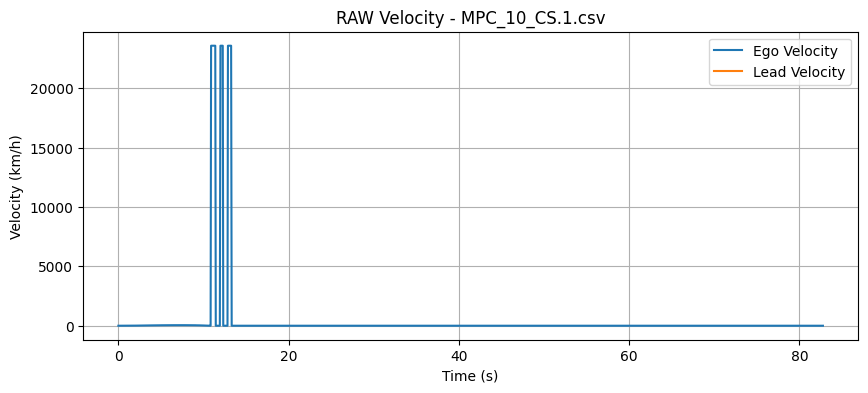

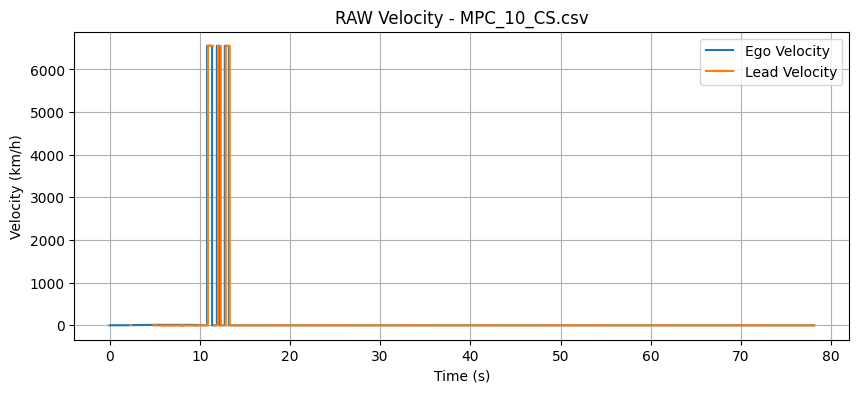

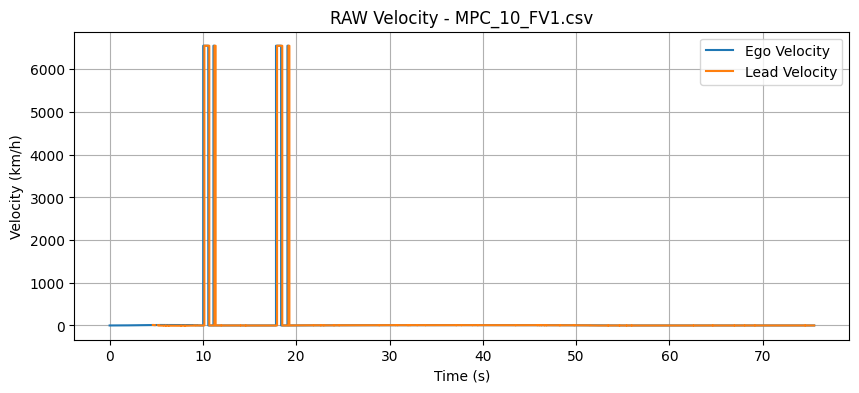

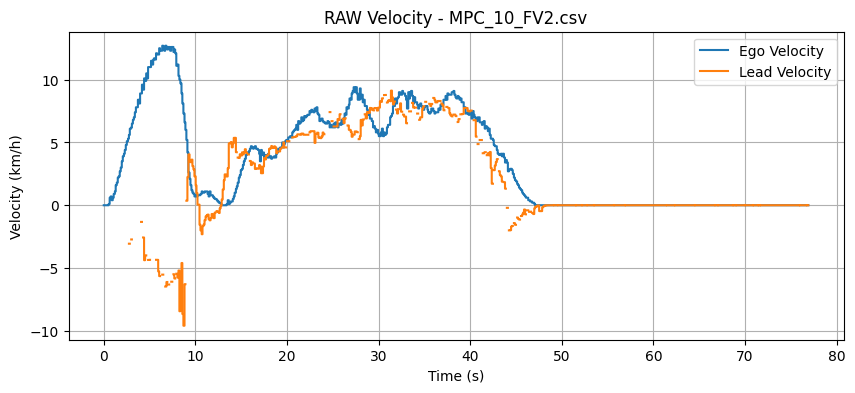

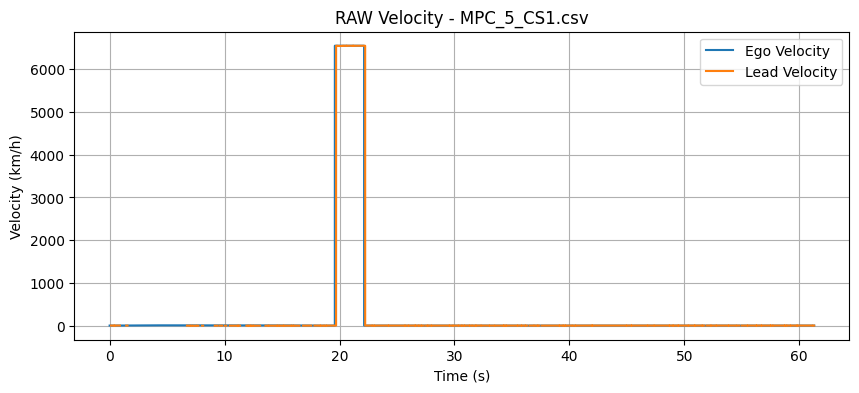

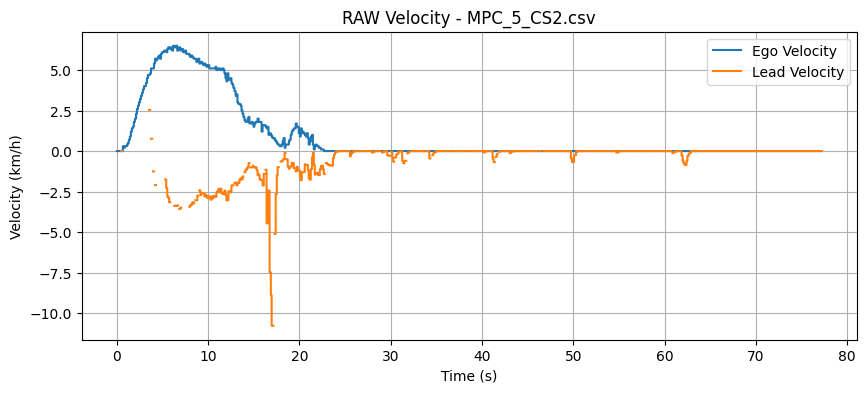

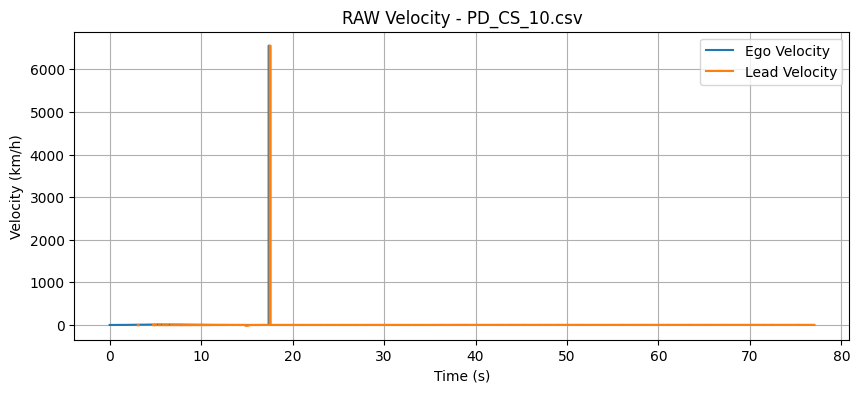

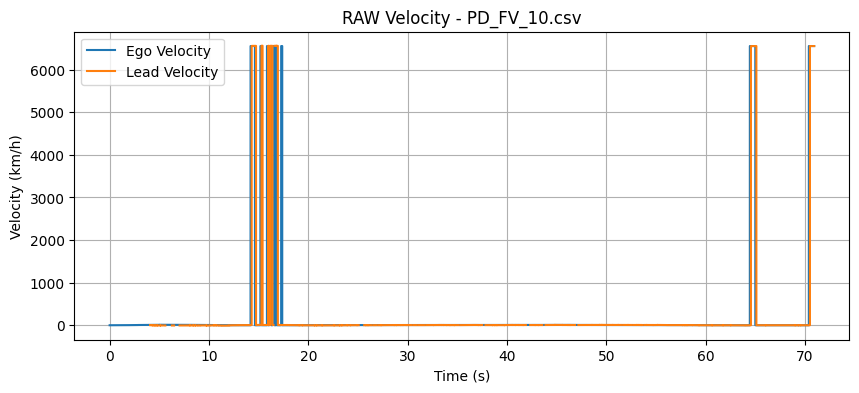

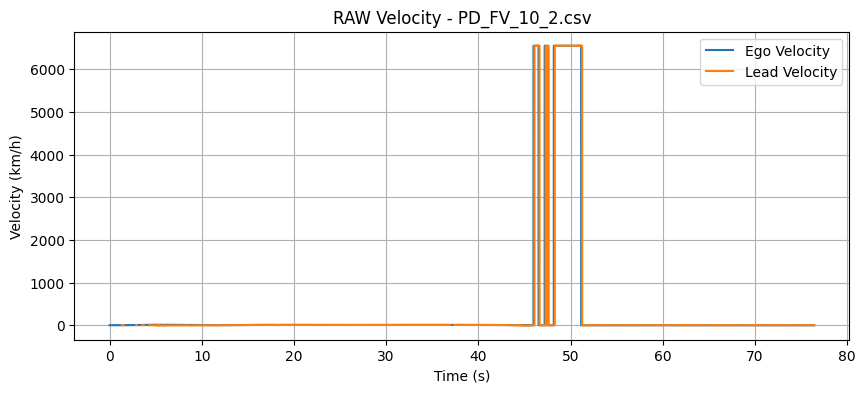

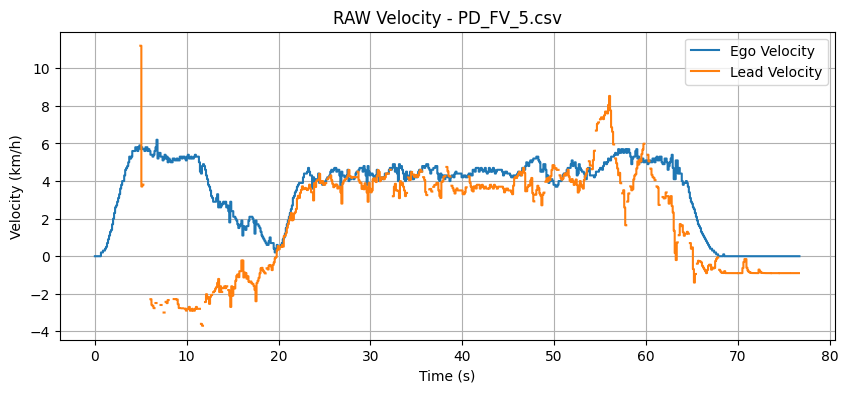

In [20]:
for i, df in enumerate(dataframes):

    plt.figure(figsize=(10,4))

    plt.plot(df["time_sec"], df["ego_velocity_kmph"], label="Ego Velocity")

    if "lead_velocity_kmph" in df:
        plt.plot(df["time_sec"], df["lead_velocity_kmph"], label="Lead Velocity")

    plt.title(f"RAW Velocity - {filenames[i]}")
    plt.xlabel("Time (s)")
    plt.ylabel("Velocity (km/h)")
    plt.legend()
    plt.grid()

    plt.show()

## For 2.2 Data Set

In [21]:
# -------- PATH --------
script_dir = os.getcwd()
csv_folder = os.path.join(script_dir, "extracted_csv")

# choose files to visualize
selected_files = [
    "MPC_5_CS1.csv"
]

data = {}

for file in selected_files:
    
    path = os.path.join(csv_folder, file)
    df = pd.read_csv(path)

    # normalize time for better plots
    df["time"] = df["ros_time"] - df["ros_time"].iloc[0]

    data[file] = df

df["time"] = df["ros_time"] - df["ros_time"].iloc[0]

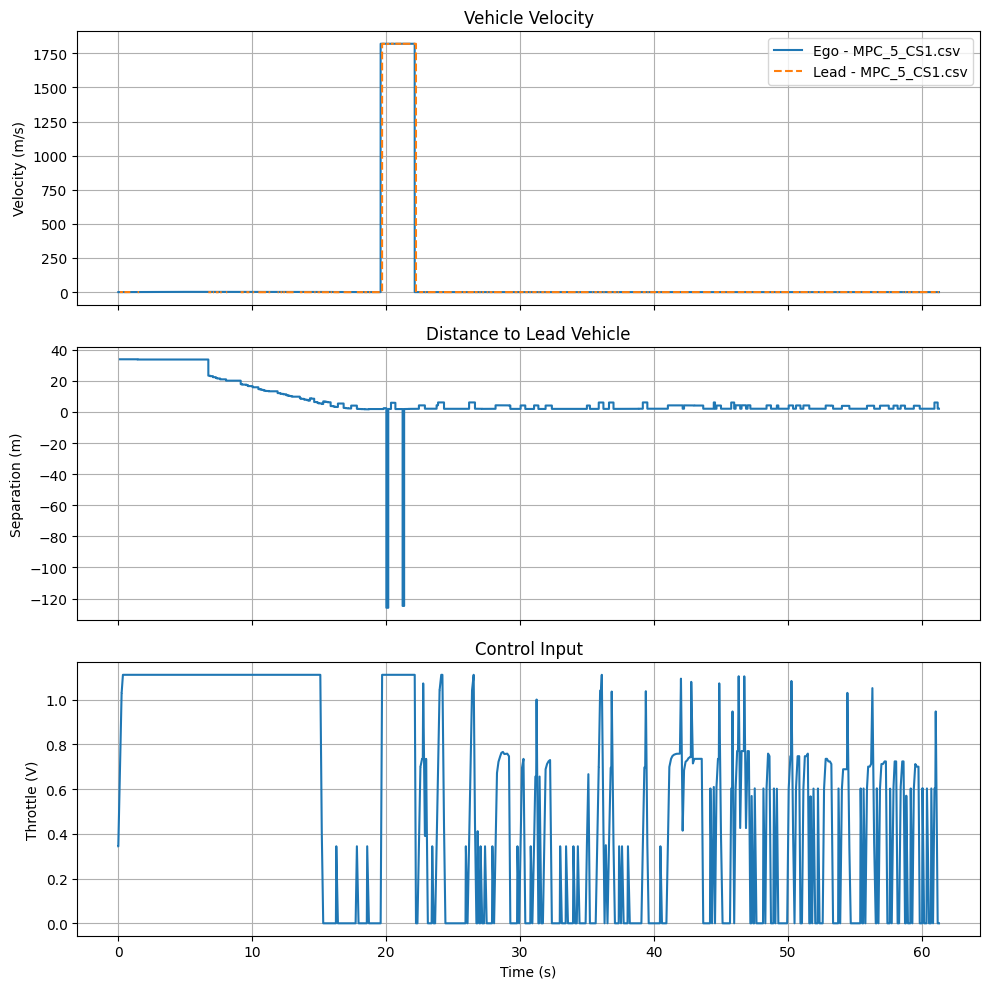

In [22]:
fig, axes = plt.subplots(3, 1, figsize=(10,10), sharex=True)

for file, df in data.items():

    # ---- Velocity ----
    axes[0].plot(df["time"], df["ego_velocity"], label=f"Ego - {file}")

    if "lead_velocity" in df.columns:
        axes[0].plot(df["time"], df["lead_velocity"], linestyle="--", label=f"Lead - {file}")

    # ---- Separation ----
    if "separation" in df.columns:
        axes[1].plot(df["time"], df["separation"], label=file)

    # ---- Throttle ----
    axes[2].plot(df["time"], df["throttle_command"], label=file)


# -------- FORMAT --------

axes[0].set_ylabel("Velocity (m/s)")
axes[0].set_title("Vehicle Velocity")

axes[1].set_ylabel("Separation (m)")
axes[1].set_title("Distance to Lead Vehicle")

axes[2].set_ylabel("Throttle (V)")
axes[2].set_xlabel("Time (s)")
axes[2].set_title("Control Input")

for ax in axes:
    ax.grid()

axes[0].legend()

plt.tight_layout()
plt.show()

## For 3.2 Data set 

In [23]:
# -------- PATH --------
script_dir = os.getcwd()
csv_folder = os.path.join(script_dir, "extracted_csv")

# choose files to visualize
selected_files = [
    "Test_PD_CompleteS_3.2.csv"
]

data = {}

for file in selected_files:
    
    path = os.path.join(csv_folder, file)
    df = pd.read_csv(path)

    # normalize time for better plots
    df["time"] = df["ros_time"] - df["ros_time"].iloc[0]

    data[file] = df

df["time"] = df["ros_time"] - df["ros_time"].iloc[0]

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\home\\Desktop\\ACC\\Auto-Cruise\\Adaptive-Cruise-Control\\Adaptive-Cruise-Control\\9_Vehicle_Testing_Results\\Testing_Using_Radar\\June3_2026\\ACC_June_4\\extracted_csv\\Test_PD_CompleteS_3.2.csv'

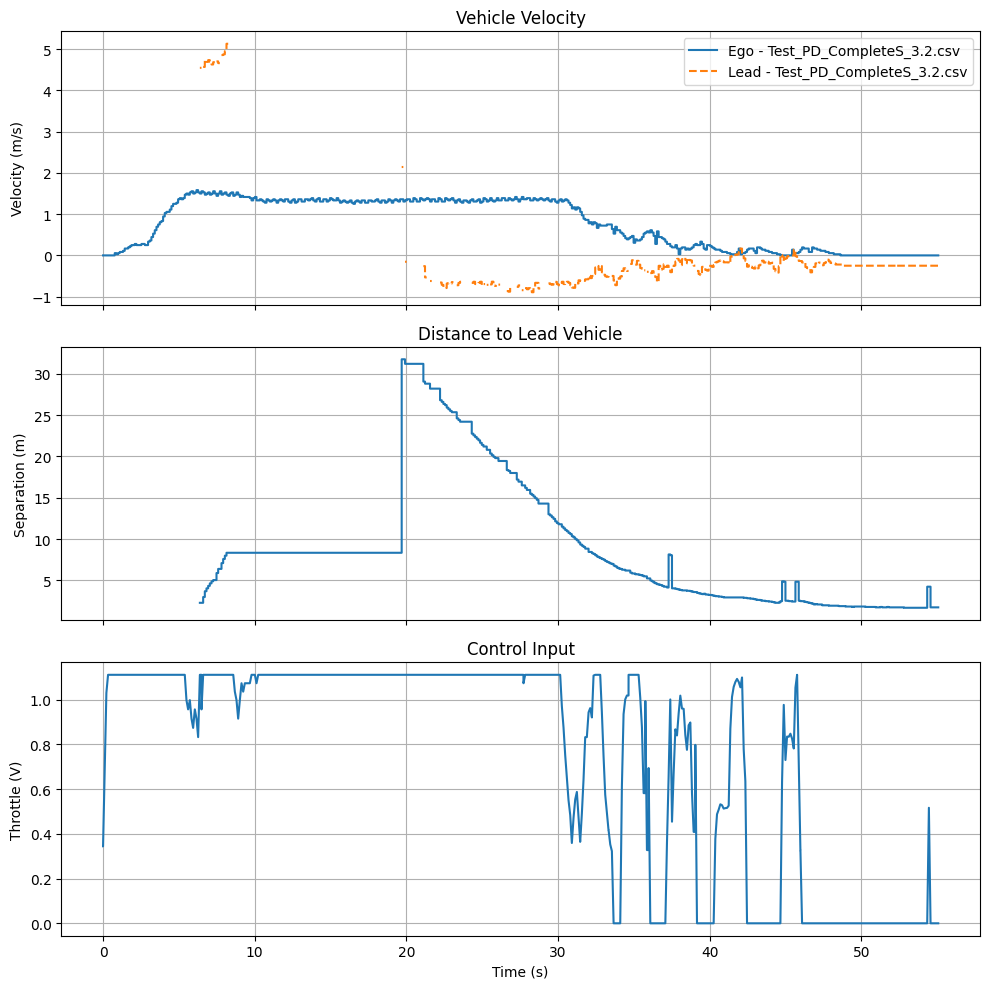

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10,10), sharex=True)

for file, df in data.items():

    # ---- Velocity ----
    axes[0].plot(df["time"], df["ego_velocity"], label=f"Ego - {file}")

    if "lead_velocity" in df.columns:
        axes[0].plot(df["time"], df["lead_velocity"], linestyle="--", label=f"Lead - {file}")

    # ---- Separation ----
    if "separation" in df.columns:
        axes[1].plot(df["time"], df["separation"], label=file)

    # ---- Throttle ----
    axes[2].plot(df["time"], df["throttle_command"], label=file)


# -------- FORMAT --------

axes[0].set_ylabel("Velocity (m/s)")
axes[0].set_title("Vehicle Velocity")

axes[1].set_ylabel("Separation (m)")
axes[1].set_title("Distance to Lead Vehicle")

axes[2].set_ylabel("Throttle (V)")
axes[2].set_xlabel("Time (s)")
axes[2].set_title("Control Input")

for ax in axes:
    ax.grid()

axes[0].legend()

plt.tight_layout()
plt.show()

## For 4.2 Data set

In [ ]:
script_dir = os.getcwd()
csv_folder = os.path.join(script_dir, "extracted_csv")

# choose files to visualize
selected_files = [
    "Test_PD_CompleteS_4.2.csv"
]

data = {}

for file in selected_files:
    
    path = os.path.join(csv_folder, file)
    df = pd.read_csv(path)

    # normalize time for better plots
    df["time"] = df["ros_time"] - df["ros_time"].iloc[0]

    data[file] = df

df["time"] = df["ros_time"] - df["ros_time"].iloc[0]

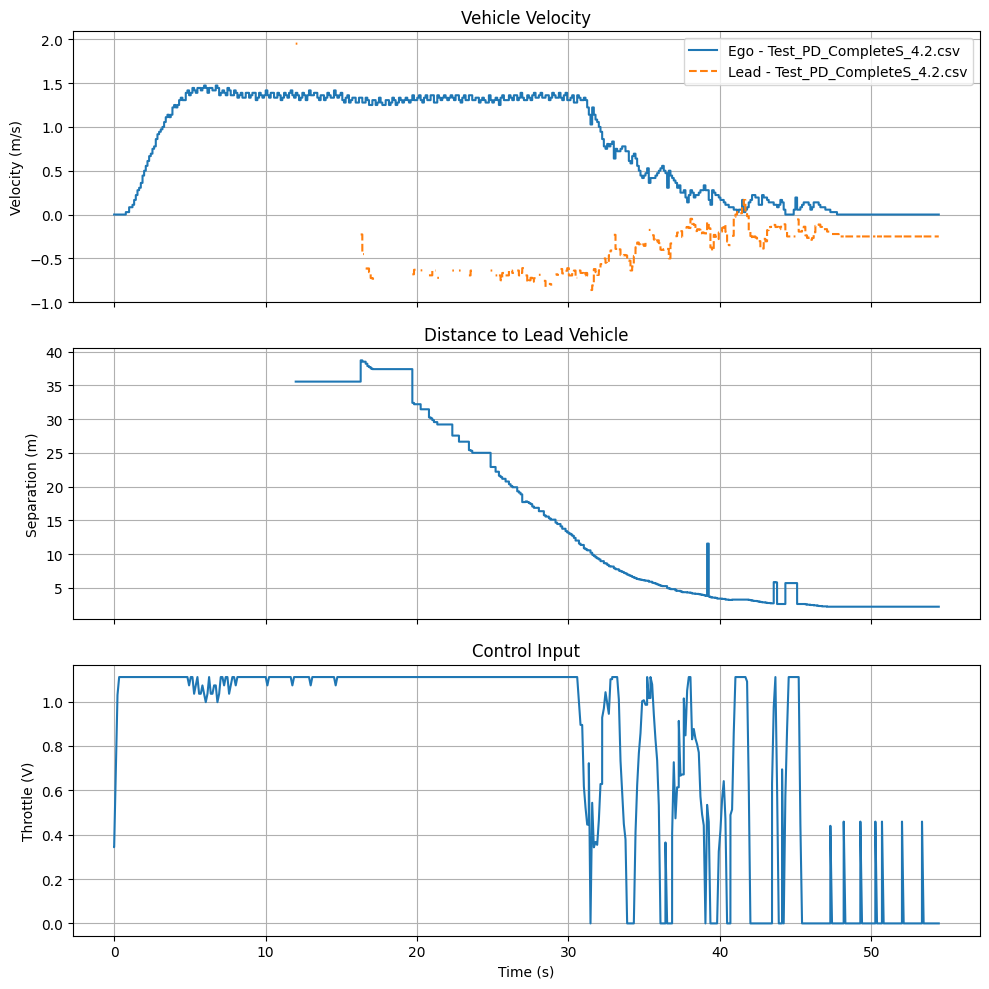

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10,10), sharex=True)

for file, df in data.items():

    # ---- Velocity ----
    axes[0].plot(df["time"], df["ego_velocity"], label=f"Ego - {file}")

    if "lead_velocity" in df.columns:
        axes[0].plot(df["time"], df["lead_velocity"], linestyle="--", label=f"Lead - {file}")

    # ---- Separation ----
    if "separation" in df.columns:
        axes[1].plot(df["time"], df["separation"], label=file)

    # ---- Throttle ----
    axes[2].plot(df["time"], df["throttle_command"], label=file)


# -------- FORMAT --------

axes[0].set_ylabel("Velocity (m/s)")
axes[0].set_title("Vehicle Velocity")

axes[1].set_ylabel("Separation (m)")
axes[1].set_title("Distance to Lead Vehicle")

axes[2].set_ylabel("Throttle (V)")
axes[2].set_xlabel("Time (s)")
axes[2].set_title("Control Input")

for ax in axes:
    ax.grid()

axes[0].legend()

plt.tight_layout()
plt.show()

## For 5.2 Dataset

In [ ]:
script_dir = os.getcwd()
csv_folder = os.path.join(script_dir, "extracted_csv")

# choose files to visualize
selected_files = [
    "Test_PD_CompleteS_5.2.csv"
]

data = {}

for file in selected_files:
    
    path = os.path.join(csv_folder, file)
    df = pd.read_csv(path)

    # normalize time for better plots
    df["time"] = df["ros_time"] - df["ros_time"].iloc[0]

    data[file] = df

df["time"] = df["ros_time"] - df["ros_time"].iloc[0]

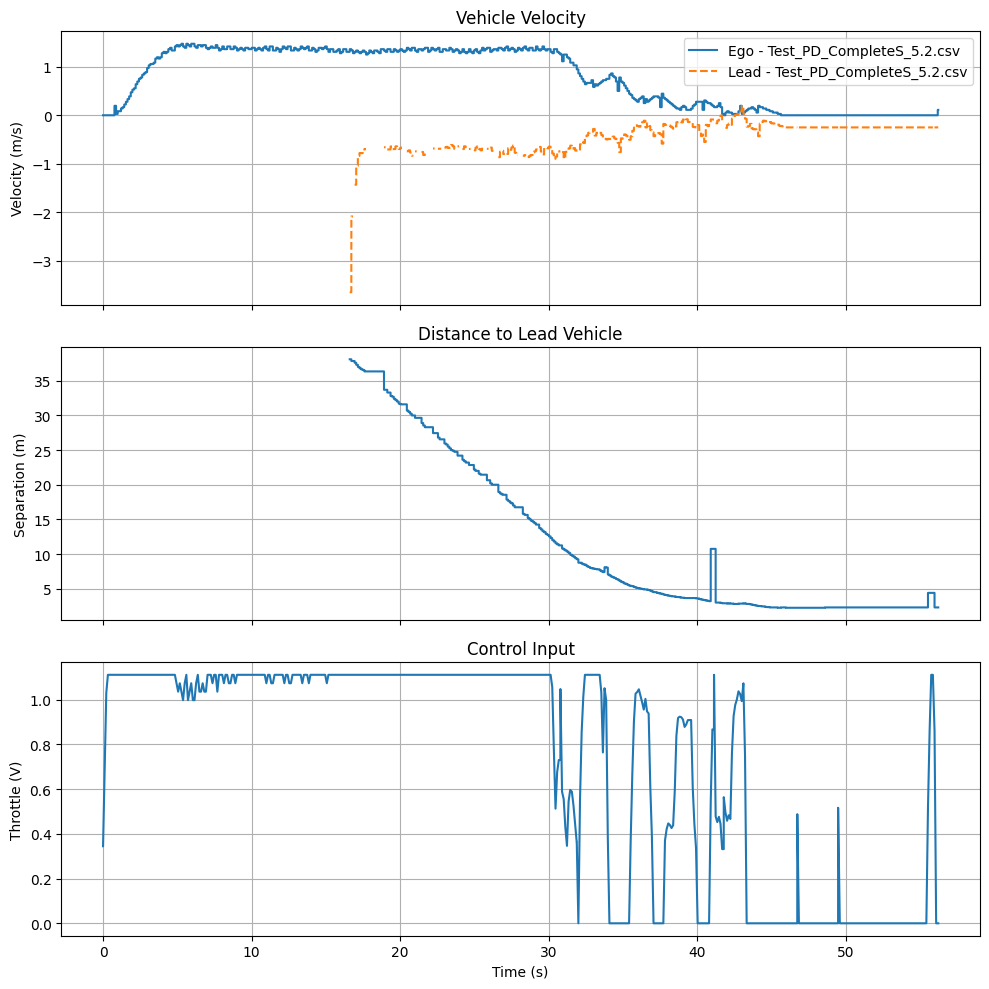

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10,10), sharex=True)

for file, df in data.items():

    # ---- Velocity ----
    axes[0].plot(df["time"], df["ego_velocity"], label=f"Ego - {file}")

    if "lead_velocity" in df.columns:
        axes[0].plot(df["time"], df["lead_velocity"], linestyle="--", label=f"Lead - {file}")

    # ---- Separation ----
    if "separation" in df.columns:
        axes[1].plot(df["time"], df["separation"], label=file)

    # ---- Throttle ----
    axes[2].plot(df["time"], df["throttle_command"], label=file)


# -------- FORMAT --------

axes[0].set_ylabel("Velocity (m/s)")
axes[0].set_title("Vehicle Velocity")

axes[1].set_ylabel("Separation (m)")
axes[1].set_title("Distance to Lead Vehicle")

axes[2].set_ylabel("Throttle (V)")
axes[2].set_xlabel("Time (s)")
axes[2].set_title("Control Input")

for ax in axes:
    ax.grid()

axes[0].legend()

plt.tight_layout()
plt.show()